In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.fixes import loguniform
from scipy.stats import uniform

from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge


from sklearn.preprocessing import LabelEncoder


Fitting 5 folds for each of 500 candidates, totalling 2500 fits
{'subsample': 1.0, 'n_estimators': 500, 'min_samples_split': 100, 'min_samples_leaf': 10, 'max_depth': 3, 'loss': 'deviance', 'learning_rate': 0.1}
AUC: 0.8618316144082754


Text(0.5, 1.0, 'Gradient Boosting Classifier Feature Importance 2020')

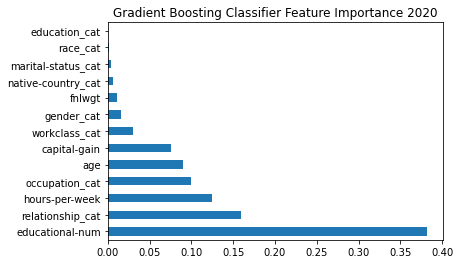

In [3]:
X = pd.read_csv("X_2020.csv")
X.drop(columns=X.columns[0], 
        axis=1, 
        inplace=True)
X = pd.get_dummies(data=X,drop_first=True)
y = pd.read_csv("y_2020.csv")
y.drop(columns=y.columns[0], 
        axis=1, 
        inplace=True)
y = pd.get_dummies(data=y,drop_first=True)
y = y.values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
gbc = GradientBoostingClassifier(n_iter_no_change=10,tol=0.001)
params = {    
    'learning_rate': [0.01, 0.1],
    'loss': ['deviance', 'exponential'],
    'max_depth': [3,  7, 15],
    'subsample':[1.0,0.5],
    'min_samples_split':[5,10,100],
    'min_samples_leaf':[ 2, 5, 10],
    'n_estimators' : [100, 200, 500],
}
grid_search = RandomizedSearchCV(n_iter=500,estimator=gbc, param_distributions=params,scoring="roc_auc",cv=5,verbose=2,n_jobs=-1)
grid_search.fit(X_train,y_train)

bestest = grid_search.best_estimator_
preds = bestest.predict_proba(X_test)
print(grid_search.best_params_)
bestest.fit(X_train, y_train)
print("AUC: " + str(roc_auc_score(y_test, preds[:,1])))
feat_importances = pd.Series(bestest.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Gradient Boosting Classifier Feature Importance 2020")


In [4]:
from sklearn.model_selection import cross_val_score
def auc_cv(model,my_X,my_y):
    score = cross_val_score(model, my_X, my_y, scoring="roc_auc", cv = 20)
    return(score)

In [5]:
X = pd.read_csv("X_2020.csv")
X.drop(columns=X.columns[0], 
        axis=1, 
        inplace=True)
X = pd.get_dummies(data=X,drop_first=True)
y = pd.read_csv("y_2020.csv")
y.drop(columns=y.columns[0], 
        axis=1, 
        inplace=True)
y = pd.get_dummies(data=y,drop_first=True)
y = y.values.ravel()
gbc = GradientBoostingClassifier(n_iter_no_change=10,tol=0.001,subsample= 1.0, n_estimators= 200, min_samples_split= 10, min_samples_leaf= 5, max_depth= 7, loss= 'exponential', learning_rate= 0.1)
score = auc_cv(gbc,X,y)
print("Average is:", np.mean(score))
print(score)

Average is: 0.857466848707306
[0.85074426 0.84362887 0.84414776 0.87331022 0.86649009 0.86092556
 0.86858501 0.80303145 0.86306115 0.86694896 0.85027861 0.86536808
 0.87439543 0.86184142 0.85432893 0.84437896 0.85673723 0.87007781
 0.8786231  0.85243407]


In [6]:
import statistics
print("Standard deviation is:",statistics.stdev(score))

Standard deviation is: 0.016543318303375066


In [7]:
X = pd.read_csv("X_1994.csv")
X.drop(columns=X.columns[0], 
        axis=1, 
        inplace=True)
X = pd.get_dummies(data=X,drop_first=True)
y = pd.read_csv("y_1994.csv")
y.drop(columns=y.columns[0], 
        axis=1, 
        inplace=True)
y = pd.get_dummies(data=y,drop_first=True)
y = y.values.ravel()
gbc = GradientBoostingClassifier(n_iter_no_change=10,tol=0.001,subsample= 1.0, n_estimators= 200, min_samples_split= 10, min_samples_leaf= 5, max_depth= 7, loss= 'exponential', learning_rate= 0.1)
score = auc_cv(gbc,X,y)
print("Average is:", np.mean(score))
print(score)
print("Standard deviation is:",statistics.stdev(score))

Average is: 0.9268418065956604
[0.92692775 0.93006945 0.92540312 0.92470763 0.92139865 0.92484935
 0.93026214 0.92507139 0.92144012 0.9346902  0.92076352 0.92323791
 0.92947373 0.92650437 0.92800723 0.92731939 0.9307927  0.93453602
 0.92432526 0.9270562 ]
Standard deviation is: 0.00394705921344649


In [8]:
print("First 3 rows of X_1994.csv")
print(X.head(3))

First 3 rows of X_1994.csv
   age    fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week  \
0   25  226802.0                7             0             0              40   
1   38   89814.0                9             0             0              50   
2   28  336951.0               12             0             0              40   

   education_cat  workclass_cat  marital-status_cat  occupation_cat  \
0              1              2                   4               6   
1             11              2                   2               4   
2              7              1                   2              10   

   relationship_cat  race_cat  gender_cat  native-country_cat  
0                 3         2           1                  38  
1                 0         4           1                  38  
2                 0         4           1                  38  
